### Fera formidável 4.3 - Derrube pra fora

#### Enunciado:
Objetivo: implemente o regularizador dropout na rede neural feita em Python puro.

Comentário: algumas tarefas vão apresentar palavras e conceitos que ainda não
vimos em sala. Parte do desafio é justamente se informar sobre estes conceitos.

Comentário 2: observe que o enunciado diz claramente que é para realizar a tarefa
na rede neural feita em Python puro nos vídeos da disciplina. Se você está usando o
PyTorch, numpy, tensorflow, keras, lightning ou qualquer outra biblioteca pronta,
você está no caminho errado!

### Introdução

Para a aplicação da estratégia de dropout na rede neural criada em python puro foram feitas alterações apenas nas classes `Camada` e `MLP`. Foi acrescentado um parâmetro para a classe `MLP` chamado `taxa_dropout`, esse parâmetro controla a porcentagem de neurônios que serão desativados em uma época. A `taxa_dropout` passa para a classe `Camada` na qual o python confere se o modelo está em modo treino, se sim, uma máscara aleatória é feita a partir de uma lista que possui valores 1 ou 0, que são multiplicados pelos respectivos neurônios de modo a zerar alguns para o dropout ser aplicado. 

Além disso, os dados que foram retornados dos neurônios precisaram de um ajuste, como é dito na literatura a partir da fórmula: $$novosdados = \frac{dadosantigos}{1-taxadropout}$$

Essa fórmula é aplicada para os dados de saída de todos os neurônios, não apenas do último neurônio que retorna o $y_{prev}$. Esse ajuste evita que os pesos mudem de escala entre treino e teste, o que poderia impedir a convergência do modelo no teste.

### Importando bibliotecas

In [1]:
import seaborn as sns
import random as rd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from classes import Valor, Neuronio, Camada, MLP
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error

### Definindo o dataset

In [2]:
df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
entradas = df.drop(columns= ["petal_width", "species"]).values
saidas = df["petal_width"].values.reshape(-1, 1)

### Dividindo os dados em treino, teste e validação e aplicando a normalização padrão 

In [4]:
TAMANHO_TESTE_E_VALIDACAO = 0.1 

# Alocando 10% dos dados para teste
entradas_temp, entradas_teste, saidas_temp, saidas_teste = train_test_split(
    entradas, saidas, test_size=TAMANHO_TESTE_E_VALIDACAO)

# Alocando 10% dos dados para validação
entradas_treino, entradas_val, saidas_treino, saidas_val = train_test_split(
    entradas_temp, saidas_temp, test_size=TAMANHO_TESTE_E_VALIDACAO)

In [5]:
normalizador = StandardScaler()
x_treino = normalizador.fit_transform(entradas_treino).tolist()
x_val = normalizador.transform(entradas_val).tolist()
x_teste = normalizador.transform(entradas_teste).tolist()

saidas_treino_norm = normalizador.fit_transform(saidas_treino).tolist()
saidas_val_norm = normalizador.transform(saidas_val).tolist()
saidas_teste_norm = normalizador.transform(saidas_teste).tolist()

y_true = [j for i in saidas_treino_norm for j in i]
y_val = [j for i in saidas_val_norm for j in i]
y_teste = [j for i in saidas_teste_norm for j in i]

### Criando o modelo `minha_MLP`

In [18]:
NUM_DADOS_DE_ENTRADA = 3
NUM_DADOS_DE_SAIDA = 1
CAMADAS_OCULTAS = [8, 4]  
TAXA_DROPOUT = 0.3

arquitetura_da_rede = CAMADAS_OCULTAS + [NUM_DADOS_DE_SAIDA]

minha_mlp = MLP(NUM_DADOS_DE_ENTRADA, arquitetura_da_rede, taxa_dropout=TAXA_DROPOUT)

### Treinando a rede neural e testando para os dados de validação

In [19]:
NUM_EPOCAS = 300
TAXA_DE_APRENDIZADO = 0.05

x_plot = []
y_plot = []
y_val_plot = []

for epoca in range(NUM_EPOCAS):
    # forward pass
    y_pred = []
    for exemplo in x_treino:
        previsao = minha_mlp(exemplo, treino= True) # Fera 4.3
        y_pred.append(previsao)
 
    # loss
    erros = []
    for yp, yt in zip(y_pred, y_true):
        residuo = yp - yt
        erro_quadratico = residuo ** 2
        erros.append(erro_quadratico)        
    loss = sum(erros)
 
    # zero grad
    for p in minha_mlp.parametros():
        p.grad = 0
 
    # backpropagation
    loss.propagar_tudo()
 
    # atualiza parâmetros
    for p in minha_mlp.parametros():
        p.data = p.data - p.grad * TAXA_DE_APRENDIZADO
        
    # validação
    y_val_pred = [minha_mlp(x, treino = False) for x in x_val] # Fera 4.3
        
    erros_val = [(yp - yt)**2 for yp, yt in zip(y_val_pred, y_val)]
    loss_val = sum(erros_val)
    
    # mostra resultado (opcional)
    print(f"Época {epoca + 1:03d} — Perda Treino: {loss.data:.4f} | Perda Validação: {loss_val.data:.4f}")
    
    if epoca != 0:
        x_plot.append(epoca)
        y_plot.append(loss.data)
        y_val_plot.append(loss_val.data)

Época 001 — Perda Treino: 161.1117 | Perda Validação: 19.7274
Época 002 — Perda Treino: 121.0027 | Perda Validação: 19.7272
Época 003 — Perda Treino: 121.0280 | Perda Validação: 19.7269
Época 004 — Perda Treino: 121.0768 | Perda Validação: 19.7269
Época 005 — Perda Treino: 120.9635 | Perda Validação: 19.7265
Época 006 — Perda Treino: 121.0167 | Perda Validação: 19.7263
Época 007 — Perda Treino: 120.7895 | Perda Validação: 19.7252
Época 008 — Perda Treino: 121.0093 | Perda Validação: 19.7249
Época 009 — Perda Treino: 121.0377 | Perda Validação: 19.7246
Época 010 — Perda Treino: 121.0384 | Perda Validação: 19.7245
Época 011 — Perda Treino: 120.8748 | Perda Validação: 19.7237
Época 012 — Perda Treino: 120.9168 | Perda Validação: 19.7230
Época 013 — Perda Treino: 120.9751 | Perda Validação: 19.7226
Época 014 — Perda Treino: 121.0057 | Perda Validação: 19.7222
Época 015 — Perda Treino: 120.9054 | Perda Validação: 19.7214
Época 016 — Perda Treino: 120.9561 | Perda Validação: 19.7208
Época 01

### Plotando o erro do modelo para análise

Erro no treinamento

O valor mínimo alcançado para a perda foi de: 8.925469706998134; Esse erro foi alcançado na época: 290


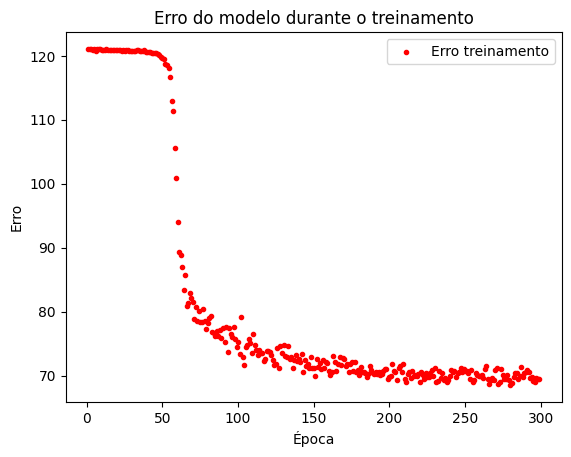

In [20]:
plt.scatter(x_plot, y_plot, color= "red", label= "Erro treinamento", marker= ".")
plt.title("Erro do modelo durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()

print(f"O valor mínimo alcançado para a perda foi de: {min(y_val_plot)}; Esse erro foi alcançado na época: {y_val_plot.index(min(y_val_plot))}")

Por esse gráfico é possível perceber um comportamento característico de uma rede neural que possui a estratégia de dropout. Durante o treinamento, se for comparado o erro de uma época com a sua anterior pode ser que ela cometa muito mais erro, entretanto, no decorrer das épocas o modelo claramente melhora, como também pode ser visto pelos plot dos erros para os dados de validação abaixo. 

Erro na validação

O valor mínimo alcançado para a perda foi de: 8.925469706998134; Esse erro foi alcançado na época: 290


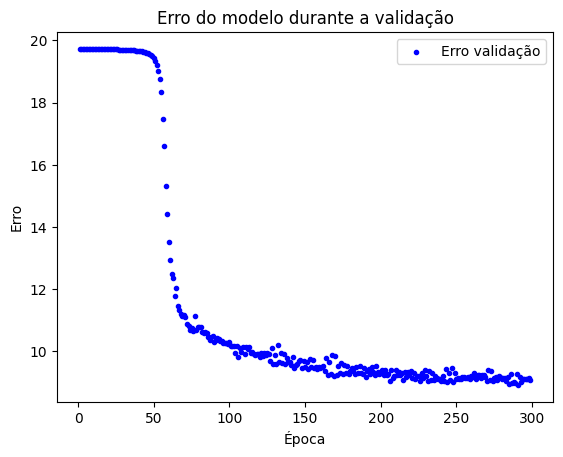

In [21]:
plt.scatter(x_plot, y_val_plot, color= "blue", label="Erro validação", marker= ".")
plt.title("Erro do modelo durante a validação")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()

print(f"O valor mínimo alcançado para a perda foi de: {min(y_val_plot)}; Esse erro foi alcançado na época: {y_val_plot.index(min(y_val_plot))}")

O gráfico mostra que o erro para os dados de validação não só diminuiram, como foram muito mais regulares do que para os dados de treino durante o treinamento da rede neural. Isso mostra que a estratégia de dropout é sim válida porque a rede neural, mesmo com neurônios faltando, consegue se adequar aos dados. 

### Testando a rede neural para os dados de teste

In [22]:
previsoes_teste = [minha_mlp(x, False) for x in x_teste]
y_teste_pred = [yp.data for yp in previsoes_teste]

RMSE = mean_squared_error(y_teste, y_teste_pred, squared=False)

print(f"O RMSE do modelo foi de {RMSE} unidades de y.")

O RMSE do modelo foi de 0.6984155522246338 unidades de y.


O resultado para o RMSE parece interessante, ainda mais considerando o número de épocas usado.

### Conclusão

O modelo com a estratégia de dropout funcionou bem, o erro para os dados de validação diminuiu apesar dos neurônios zerados. Foi possível perceber a importância do cálculo para ajustar os neurônios não zerados para que eles pudessem suprir a falta dos demais. De uma maneira geral a estratégia de dropout parece funcionar muito bem e pode ser muito útil em casos nos quais o overfitting é fácil de ser alcançado. 

### Referências

Cassar, Daniel R. Material didático redes neurais do ano de 2025.

DSA, E. Capítulo 23 - Como Funciona o Dropout? - Deep Learning Book. Disponível em: <https://www.deeplearningbook.com.br/como-funciona-o-dropout/>. Acesso em: 27 maio. 2025.

YADAV, H. Dropout in Neural Networks | Towards Data Science. Disponível em: <https://towardsdatascience.com/dropout-in-neural-networks-47a162d621d9/>.

KASHYAP, P. Understanding Dropout in Deep Learning: A Guide to Reducing Overfitting. Disponível em: <https://medium.com/@piyushkashyap045/understanding-dropout-in-deep-learning-a-guide-to-reducing-overfitting-26cbb68d5575>.

